# Projeto - A Estrada da Visionária
**Autora —** Lívia Maria Aragão | **Colaboradora —** Gisela Ceresér Kassick

**Disciplina —** Redes Neurais | **Professor —** Prof. Dr. Daniel Cassar

## Introdução
O notebook abaixo aplica uma rede neural MLP classificar texturas analisadas em dispositivos de papel com grafite. Os dados utilizados foram obtidas ao pressionar as amostras sobre os dispositivos, com auxílio de um analisador de parâmetros e uma balança, contendo informações de corrente, tempo e massa (noção de força), por exmplo. O objetivo prinicpal é analisar se uma arquitetura simples de rede neural conseguiria correlacionar medições elétricas com uma caracterítica do material.

## Parâmetros gerais

In [1]:
# Importações de bibliotecas e funções necessárias
import pandas as pd
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

C:\Users\livia25013\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\venvs\ilumpy\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


In [2]:
# Reprodutibilidade
SEMENTE_ALEATORIA = 42
random.seed(SEMENTE_ALEATORIA)
np.random.seed(SEMENTE_ALEATORIA)
torch.manual_seed(SEMENTE_ALEATORIA)
torch.cuda.manual_seed_all(SEMENTE_ALEATORIA)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Configurações
PASTA_DADOS       = "dados"
TAMANHO_TESTE     = 0.10
TAMANHO_VALIDACAO = 0.10
EPOCAS            = 300
LR                = 1e-3
JANELA            = 20        
PASSO             = 1
ATRIBUTOS         = ['variacao_relativa', 'massa_g']
TARGET            = 'rotulo'
N_CLASSES         = 3

## Carregamento de dados
Obtenção dos dados coletados e pré-tratados das medições experimentais de cada dispositivo. Cada tabela contém o tempo, o valor de corrente, a tensão, a variação relativa de corrente, a massa medida na balança (noção de força) das medições; a textura analisada (`rotulo` - 0 = **Parafilm**, 1 = **Papel texturizado**, 2 = **Lixa**); e algumas outras informações sobre a extração de dados dos vídeos. Para entender melhor, leia as seções Medidas e Tratamento de Dados no README do GitHub do Projeto (https://github.com/GiselaCK/dispositivo-de-papel.git).

O _dataset_ final reuniu todas as medidas elétricas dos doze dispositvos. Foram feitas 130 medidas de cada amostra, totalizando 1560 dados.

In [4]:
dfs = {}
for arquivo in sorted(Path(PASTA_DADOS).glob("Completo_Amostra*.csv")):
    nome = arquivo.stem.split("_")[1]
    dfs[nome] = pd.read_csv(arquivo)
 
df_disps = pd.concat(dfs.values(), ignore_index=True)
df_disps.to_csv("dados_dispositivos.csv", index=False, encoding="utf-8-sig")
print(f"Shape total: {df_disps.shape}")

print('Dataset final:')
print()
print(df_disps)

Shape total: (1560, 9)
Dataset final:

              t         I    V  variacao_relativa  massa_g  ocr_bruto  \
0      0.672535  0.000009  0.5           0.053400      0.0        0.0   
1      1.196415  0.000009  0.5           0.047805      0.0        0.0   
2      1.720301  0.000009  0.5           0.056779      0.0        0.0   
3      2.244206  0.000009  0.5           0.047418      7.0        7.0   
4      2.768098  0.000009  0.5           0.046253      7.0        7.0   
...         ...       ...  ...                ...      ...        ...   
1555  66.158920  0.000023  0.5           0.136046    500.0        0.0   
1556  66.682800  0.000023  0.5           0.132241    500.0        0.0   
1557  67.206696  0.000023  0.5           0.133193    500.0        0.0   
1558  67.730591  0.000023  0.5           0.141836    500.0        0.0   
1559  68.254486  0.000023  0.5           0.142649    500.0        0.0   

              estrategia           correcao  rotulo  
0                nenhuma      

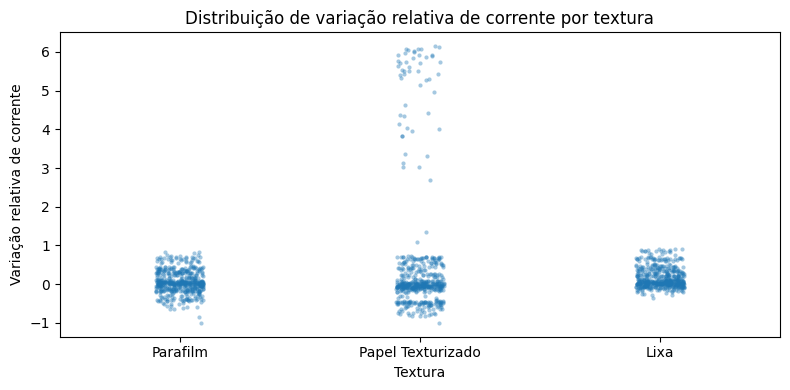

In [5]:
plt.figure(figsize=(8, 4))

sns.stripplot(
    data=df_disps,
    x="rotulo",
    y="variacao_relativa",
    alpha=0.4,
    size=3
)

plt.title("Distribuição de variação relativa de corrente por textura")
plt.xticks(ticks=[0, 1, 2], labels=["Parafilm", "Papel Texturizado", "Lixa"])
plt.xlabel("Textura")
plt.ylabel("Variação relativa de corrente")
plt.tight_layout()
plt.show()

## Estratégia - Janelas Temporais
O procedimento experimental trabalhou com variação da medida de corrente pela variação da aplicação de pressão ao longo do tempo. Dessa maneira, decidiu-se trabalhar com uma estratégia de agrupamento dos dados em intervalos de 20 s, em janelas temporais.

In [6]:
def criar_janelas(df, atributos, target, janela, passo):
    X, y = [], []
    valores = df[atributos].values
    rotulos = df[target].values
    for i in range(0, len(df) - janela, passo):
        X.append(valores[i : i + janela])
        y.append(rotulos[i + janela - 1])
    return np.array(X), np.array(y)
 
X, y = criar_janelas(df_disps, ATRIBUTOS, TARGET, JANELA, PASSO)
print(f"Janelas: X={X.shape}  y={y.shape}")

Janelas: X=(1540, 20, 2)  y=(1540,)


## Divisão treino/validação/teste
Separação dos dados para as diferentes etapas da rede.

In [7]:
indices = np.arange(len(X))
idx_tv, idx_teste = train_test_split(indices, test_size=TAMANHO_TESTE,
                                     random_state=SEMENTE_ALEATORIA)
idx_treino, idx_val = train_test_split(idx_tv,
                                       test_size=TAMANHO_VALIDACAO / (1 - TAMANHO_TESTE),
                                       random_state=SEMENTE_ALEATORIA)
 
X_treino, y_treino = X[idx_treino], y[idx_treino]
X_val,    y_val    = X[idx_val],    y[idx_val]
X_teste,  y_teste  = X[idx_teste],  y[idx_teste]

## Normalização 
Ajuste de dados para deixá-los em uma mesma escala. Nesse caso, foi utilizado o `StandardScaler`, que transforma cada feature para ter média 0 e desvio padrão 1. Para os dados trabalhados, isso é vantajoso pois a massa e a variação de corrente estão em escalas muito distintas. Assim, é possível aproximar os gradientes e, por consequência, melhorar a eficiência dos otimizadores na MLP. 

In [8]:
n_feat = len(ATRIBUTOS)
scaler = StandardScaler()
scaler.fit(X_treino.reshape(-1, n_feat))
 
X_treino = scaler.transform(X_treino.reshape(-1, n_feat)).reshape(X_treino.shape)
X_val    = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_teste  = scaler.transform(X_teste.reshape(-1, n_feat)).reshape(X_teste.shape)
 
 
def para_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return Xt, yt
 
X_tr, y_tr = para_tensor(X_treino, y_treino)
X_vl, y_vl = para_tensor(X_val,    y_val)
X_ts, y_ts = para_tensor(X_teste,  y_teste)

## Arquitetura - MLP
Considerando a dimensão baixa dos dados, com 2 _features_, 3 classes e apenas 1540 dados (pós janelas), a primeira hipótese é justamente modular o problema utilizando uma arquiteura mais básica de rede neural: uma _Multi-Layer Perceptron_ (MLP). [1]

Para tal, foi criada uma rede com camadas lineares, ativações do tipo ReLU (introdução de não-linearidade) e uma estratégia de regularização por Dropout (evitar overfitting pelo deligamento de uma parte dos neurônios). A estrutura gera uma progressão: entrada = 2 (features) -> 32 (neurônios) -> 16 (neurôrios) -> 3 (classes) = saída, permitindo expandir primeiro e comprimir depois e, assim, abrindo um leque maior de possibilidades de aprendizado para serem afuniladas nas mais relevantes. [2]

Vale ressaltar que MLPs não lidam muito bem dados temporais. [4] Além disso, as camadas lineares esperam uma entrada 2D [2], mas a estratégia de janelas cria uma dimensão a mais, decorrente do tempo. Por isso, no passo _foward_ é feito o colapso temporal, reestabelecendo a estrutura ideal para a MLP, mantendo apenas noção de uma média de um intervalo, sem uma real sequência de dados. 

A rede abaixo foi construída em PyTorch. [3]

In [9]:
class DispositivosMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 3)
         )
    
    def forward(self, x):
        x = x.mean(dim=1)
        return self.net(x)

## Instância do Modelo
Definição e chamada do modelo, junto da função de perda adequada ao problema de classificação, `CrossEntropyLoss`, e do otimizador escolhido, `Adam`, com a taxa de aprendizado do modelo.

In [10]:
model = DispositivosMLP()
fn_perda = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## Treino e Validação
Fit dos dados do dataset, tratados, normalizados e transformados em tensores, ao modelo. Serão acompanhados as perdas e as acurácias, métrica de classificação, para o treino e a validação.

In [11]:
train_losses, val_losses = [], []
 
for epoca in range(EPOCAS):
    model.train()
    optimizer.zero_grad()
    loss = fn_perda(model(X_tr), y_tr)   
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
 
    model.eval()
    with torch.no_grad():
        out_vl = model(X_vl)   
        out_tr = model(X_tr)
 
        val_loss = fn_perda(out_vl, y_vl).item()
        val_losses.append(val_loss)
 
        # para acurácia: soma spikes ao longo do tempo → argmax
        acc_tr = (out_tr.argmax(1) == y_tr).float().mean().item() * 100
        acc_vl = (out_vl.argmax(1) == y_vl).float().mean().item() * 100
 
        if epoca % 50 == 0 or epoca == EPOCAS - 1:
            print(f"Época {epoca:4d} | loss treino: {loss.item():.4f} "
                  f"| loss val: {val_loss:.4f} "
                  f"| acc treino: {acc_tr:.2f}% | acc val: {acc_vl:.2f}%")

Época    0 | loss treino: 1.1093 | loss val: 1.0911 | acc treino: 36.28% | acc val: 41.56%
Época   50 | loss treino: 1.0614 | loss val: 1.0507 | acc treino: 37.50% | acc val: 42.21%
Época  100 | loss treino: 1.0371 | loss val: 1.0182 | acc treino: 45.29% | acc val: 46.10%
Época  150 | loss treino: 1.0063 | loss val: 0.9787 | acc treino: 44.64% | acc val: 44.16%
Época  200 | loss treino: 0.9935 | loss val: 0.9583 | acc treino: 44.56% | acc val: 42.21%
Época  250 | loss treino: 0.9768 | loss val: 0.9470 | acc treino: 45.05% | acc val: 47.40%
Época  299 | loss treino: 0.9735 | loss val: 0.9423 | acc treino: 44.81% | acc val: 43.51%


## Teste
Avaliação do desempenho do modelo, frente a dados não vistos anteriormente.

In [12]:
model.eval()
with torch.no_grad():
    preds = preds = model(X_ts).argmax(dim=1) 
 
acc = (preds == y_ts).float().mean().item() * 100
print(f"\nAcurácia - Teste: {acc:.2f}%")


Acurácia - Teste: 45.45%


## Curvas de perda - Treino x Validação
Acompanhamento gráfico das perdas do modelo ao longo das épocas, no treino e na validação.

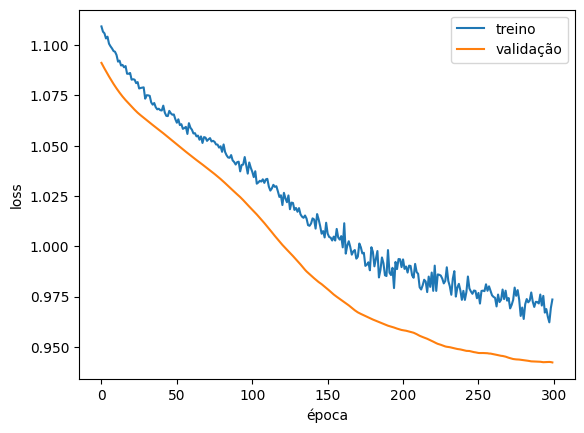

In [13]:
plt.plot(train_losses, label="treino")
plt.plot(val_losses,   label="validação")
plt.xlabel("época")
plt.ylabel("loss")
plt.legend()
plt.show()

## Relatório de classificação e matriz de confusão
Outras formas de visualizar e analisar a performance do modelo. O relatório de classificação reúne uma série de métricas desse tipo para unir difernetes visões dos dados. Já a matriz de confusão reflete as previsões do modelo por uma relação classe real x prevista, permitindo elucidar sobre a assertividade por categorias.

                   precision    recall  f1-score   support

         Parafilm       0.27      0.17      0.21        47
Papel texturizado       0.75      0.40      0.53        52
             Lixa       0.43      0.75      0.54        55

         accuracy                           0.45       154
        macro avg       0.48      0.44      0.43       154
     weighted avg       0.49      0.45      0.43       154



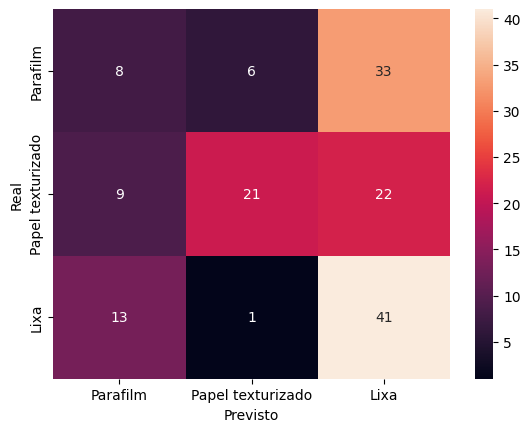

In [14]:
texturas = ["Parafilm", "Papel texturizado", "Lixa"]
print(classification_report(y_ts.numpy(), preds.numpy(), target_names=texturas))
 
cm = confusion_matrix(y_ts.numpy(), preds.numpy())
sns.heatmap(cm, annot=True, fmt='d', 
           xticklabels=texturas,
           yticklabels=texturas)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Resultados e Discussões
O modelo MLP foi utilizado para classificar três texturas — Parafilm, Papel Texturizado e Lixa — a partir das features experimentais de variação relativa da corrente e massa aplicada, com uma estratégia de janelas temporais para capturar a dinâmica da resposta elétrica ao longo da varredura de pressão.

A acurácia final foi de 45,45%, superior ao nível aleatório de 33%, mas sem diferenciação expressiva. As curvas de perda indicam o aprendizado do modelo, porém a convergência não é alacançada, dando indícios que alguma problemática está ocorrendo.

O relatório de classificação revelou desempenho heterogêneo entre as classes. A Lixa obteve o melhor F1-score (0.54), com recall elevado mas precision moderada, indicando sobreposição na fronteira de decisão. O Papel Texturizado apresentou precision alta (0.75) e recall baixo (0.40), ou seja, o modelo prediz essa classe com cautela, mas acerta com frequência quando o faz. O Parafilm obteve o pior desempenho em todas as métricas (F1 = 0.21), sendo a classe que o modelo menos conseguiu aprender. A matriz de confusão reforçou essas tendências. [5]

Diversas estratégias foram exploradas durante o desenvolvimento — seleção de features, normalização, regularização por Dropout e análise do split por dispositivo —, mas o desempenho permaneceu limitado. A raiz do problema está nos dados experimentais: com apenas 4 dispositivos fabricados por textura e sobreposição significativa dos valores elétricos entre as classes, o modelo não tem exemplos suficientes para distinguir o que é intrínseco à textura do que é variabilidade de fabricação. A ampliação da base experimental é o caminho mais direto para superar esse teto de desempenho.

## Conclusão 
Portanto, os resultados indicam que a abordagem de MLP com features elétricas é promissora, mas requer uma base experimental mais ampla para consolidar a capacidade de generalização do sistema. A reelaboração da metodologia empreendida conhecendo melhor os limites e as possibilidades do processo é uma perspectiva do trabalho. Dessa maneira, acredita-se que o modelo poderia ser aplicado novamente e obter melhores desempenhos e capacidade de generalização, se afastado de questôes como uma acurácia não tão relevante e fortes confusões entre as classses. Assim, a hipoótese aprensentada de uma arquitetura simples de rede neural conseguiria correlacionar medições elétricas com uma caracterítica do material poderia ser afirmada com maior confiança.

## Referências
1. CASSAR, D. Class Materials. Redes Neurais e Algoritmos Genéticos - T25.
2. WIKIPEDIA CONTRIBUTORS. Multilayer perceptron. Disponível em: <https://en.wikipedia.org/wiki/Multilayer_perceptron>.
3. MLP — Torchvision main documentation. Disponível em: <https://docs.pytorch.org/vision/main/generated/torchvision.ops.MLP.html>.
4. PARK, H. et al. Differential Via Modeling Using Multilayer Perceptron-Sequential (MLP-SEQ) Neural Network. 2025 IEEE International Symposium on Electromagnetic Compatibility, Signal & Power Integrity (EMC+SIPI), p. 114–119, 18 ago. 2025.
5. WIJAYA, C. Y. Breaking Down the Classification Report from Scikit-Learn - NBD Lite #6. Disponível em: <https://www.nb-data.com/p/breaking-down-the-classification>.